# 1. Problem Explanation

## Explanation
The problem at hand involves classifying messages as either "spam" or "ham" (non-spam). This is a classic example of a binary classification task, where we aim to train a machine learning model that can automatically sort incoming messages based on their content. The significance of solving this problem lies in various applications, such as email filtering systems, SMS spam detection, and maintaining the integrity of messaging platforms.

Spam messages are often unsolicited and can contain phishing links, scams, or unwanted advertisements. Being able to filter these out can save users time and protect them from potential threats. On the other hand, ham messages are regular, non-spam messages that are important to the user. It's crucial that the system has a high accuracy in classifying spam to avoid false positives, which could result in important messages being mistakenly labeled as spam.


```
# Pseudocode for a classification decision
if message_contains_spam_keywords(message):
    classify_as_spam()
else:
    classify_as_ham()
```
The pseudocode above represents a very simplified logic that a spam filter might use, where a message is classified as spam if it contains certain keywords. This is not how modern classifiers work, but it gives a beginner an idea of the decision-making process involved in classification. The actual implementation will use a machine learning algorithm to learn from data which messages are spam or ham.

Next, we'll move on to the Dataset Exploration step. Let's load the dataset you've provided and start exploring it to understand its structure.

# 2. Importing Libraries

To work with our dataset and eventually apply the KNN algorithm, we need to import several libraries:

- numpy: Provides support for efficient numerical operations.
- pandas: Essential for data manipulation and analysis.
- matplotlib and seaborn: Used for data visualization.
- sklearn: This is the library that contains a variety of machine learning algorithms, including KNN, as well as utilities for data preprocessing, model evaluation, etc.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Dataset Exploration

Link to dataset: https://www.kaggle.com/datasets/venky73/spam-mails-dataset/data

The dataset we are working with is structured as a CSV file with 5171 entries, each representing an email message. It contains the following columns:


In [2]:
data = pd.read_csv("spam_ham_dataset.csv")

- **unnamed**: an index or identifier for each message.

- **label**: This is a string indicating whether the message is 'spam' or 'ham'

- **text**: The content of the email message

- **label_num**: A numerical representation of the label column, where '0' corresponds to 'ham' and '1' corresponds to 'spam'


    For our machine learning task, the text column will serve as the feature (input), while label_num will be the target (output) we want our model to predict.

In [3]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


# 4. Data Analysis
Explanation
In this section, we'll take a closer look at our dataset to understand the distribution of classes (spam vs. ham), identify any patterns or anomalies, and prepare the data for the machine learning model. This will involve statistical analysis, visualization, and preprocessing.

We'll start by visualizing the distribution of spam and ham messages in the dataset, and then we'll perform some basic text analysis. Let's begin with the distribution of classes.

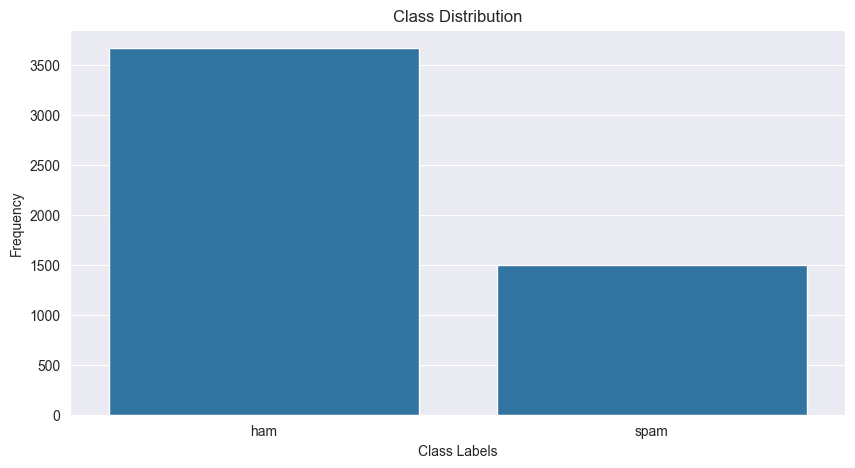

In [4]:
# Class Balance Analysis
class_counts = data["label"].value_counts()

# Plot the class distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Frequency")
plt.xlabel("Class Labels")
plt.show()

The bar plot above illustrates the distribution of spam and ham messages within our dataset. From this visualization, we can observe whether there's a significant imbalance between the two classes.

Based on the plot, it looks like there are more ham messages than spam messages, which is typical in real-world scenarios where legitimate messages usually outnumber spam. It's important to consider this imbalance when training our machine learning model, as it may lead to a model that's biased towards predicting the majority class. To address this, we might explore techniques such as resampling the dataset, using different evaluation metrics, or adjusting the class weights in the machine learning algorithm.

## Word Frequency Analysis:

In [5]:
from collections import Counter

In [6]:
data[data['label'] == "ham"]["text"]

0       Subject: enron methanol ; meter # : 988291\r\n...
1       Subject: hpl nom for january 9 , 2001\r\n( see...
2       Subject: neon retreat\r\nho ho ho , we ' re ar...
4       Subject: re : indian springs\r\nthis deal is t...
5       Subject: ehronline web address change\r\nthis ...
                              ...                        
5165    Subject: fw : crosstex energy , driscoll ranch...
5166    Subject: put the 10 on the ft\r\nthe transport...
5167    Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168    Subject: calpine daily gas nomination\r\n>\r\n...
5169    Subject: industrial worksheets for august 2000...
Name: text, Length: 3672, dtype: object

In [7]:
def get_most_common_words(class_label, num_words, column_name, dataset):
    text = " ".join(email for email in dataset[dataset['label'] == class_label][column_name])
    words = text.lower().split()
    return Counter(words).most_common(num_words)

In [8]:
spam_words = get_most_common_words("spam", 20, "text", data)
ham_words = get_most_common_words("ham", 20, "text", data)

In [9]:
spam_words

[('.', 19489),
 (',', 11227),
 ('-', 7941),
 ('the', 7254),
 ('/', 5707),
 ('to', 5160),
 ('and', 4903),
 (':', 4612),
 ('of', 4490),
 ('a', 3787),
 ('in', 3129),
 ('=', 3091),
 ('you', 2794),
 ('for', 2523),
 ('!', 2458),
 ('this', 2283),
 ('is', 2256),
 ('your', 1946),
 ('?', 1928),
 ("'", 1762)]

In [10]:
ham_words

[('-', 77782),
 ('/', 37141),
 ('.', 35192),
 (',', 29413),
 (':', 20492),
 ('the', 18359),
 ('to', 15172),
 ('ect', 13897),
 ('@', 12168),
 ('for', 7982),
 ('and', 7912),
 ('hou', 7281),
 ('enron', 6555),
 ('on', 6049),
 ('a', 6026),
 ("'", 5780),
 ('of', 5677),
 ('>', 5559),
 ('you', 5365),
 ('i', 5241)]

For ham messages, the most common items are often punctuation marks and common English words, along with some email-specific terms like 'ect' (possibly a truncated version of 'etcetera' or a specific term) and 'enron'.

For spam messages, again punctuation marks and common English words are frequent, but there are also indicators of spam content such as exclamation marks and sales or urgency-related words like 'free', '!', and '?'.

## Text Length Analysis

In [11]:
len("this is a spam email")

20

In [12]:
data["text_length"] = data["text"].apply(len)

In [13]:
data.head()

,Unnamed: 0,label,text,label_num,text_length
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,336


In [14]:
data.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,3672.0,977.008170,1382.827493,18.0,231.75,530.0,1227.25,32258.0
spam,1499.0,1223.256171,1825.986210,11.0,283.00,576.0,1253.50,22073.0


The descriptive statistics for the length of messages in each class show that spam messages tend to be slightly longer on average compared to ham messages. However, both types of messages have a wide range of lengths, as indicated by the standard deviation and the maximum length.

Ham messages have a mean length of 977 characters and a maximum length of 32,258 characters.
Spam messages have a mean length of 1223 characters and a maximum length of 22,073 characters.

## Cleaning punctuation and most common words

In [15]:
import string 
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [16]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [17]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    text = " ".join(words)
    return text

In [18]:
message = data["text"].values[0]

In [19]:
preprocess_text(message)

'subject enron methanol meter 988291 follow note gave monday 4 3 00 preliminary flow data provided daren override pop s daily volume presently zero reflect daily activity obtain gas control change needed asap economics purposes'

In [20]:
data["cleaned_text"] = data["text"].apply(preprocess_text)

In [21]:
data.head()

,Unnamed: 0,label,text,label_num,text_length,cleaned_text
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327,subject enron methanol meter 988291 follow not...
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,subject hpl nom january 9 2001 attached file h...
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,subject neon retreat ho ho ho wonderful time y...
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,414,subject photoshop windows office cheap main tr...
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,336,subject indian springs deal book teco pvr reve...


In [22]:
spam_words = get_most_common_words("spam", 20, "cleaned_text", data)
ham_words = get_most_common_words("ham", 20, "cleaned_text", data)

In [23]:
spam_words

[('subject', 1657),
 ('s', 1316),
 ('3', 1239),
 ('com', 992),
 ('http', 983),
 ('2', 858),
 ('company', 728),
 ('1', 720),
 ('0', 698),
 ('e', 631),
 ('www', 587),
 ('00', 585),
 ('information', 520),
 ('font', 515),
 ('5', 510),
 ('td', 504),
 ('t', 502),
 ('4', 494),
 ('statements', 476),
 ('email', 474)]

In [24]:
ham_words

[('ect', 13897),
 ('hou', 7281),
 ('enron', 6555),
 ('subject', 6403),
 ('2000', 4308),
 ('gas', 2861),
 ('deal', 2789),
 ('com', 2717),
 ('meter', 2459),
 ('cc', 2359),
 ('pm', 2325),
 ('hpl', 2318),
 ('s', 2111),
 ('2001', 2024),
 ('1', 2023),
 ('daren', 1901),
 ('000', 1880),
 ('00', 1819),
 ('10', 1815),
 ('thanks', 1813)]

# 5. Selected ML Algorithm Tutorial: K-Nearest Neighbors (KNN)


The K-Nearest Neighbors (KNN) algorithm is a simple, yet effective machine learning algorithm used for classification and regression tasks. In the context of our spam detection problem, we will be using it for classification. KNN works on the principle of feature similarity: a new instance is classified by a majority vote of its neighbors, with the instance being assigned to the class most common among its
k nearest neighbors.

For KNN to work with text data, we first need to convert the text into a set of numerical features. This is typically done using techniques like Bag of Words or TF-IDF. We will use the Bag of Words model, which involves the following steps:

1. Tokenization: Splitting text into individual words.
2. Vocabulary Building: Creating a vocabulary of all the unique words in the dataset.
3. Encoding: Transforming each text into a numerical vector based on the vocabulary.


The value of k (the number of neighbors to consider) is a hyperparameter that can be tuned. A small value for k can make the algorithm sensitive to noise in the data, while a large value makes it computationally expensive and may include features that are less relevant.